In [1]:
import numpy as np

In [2]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

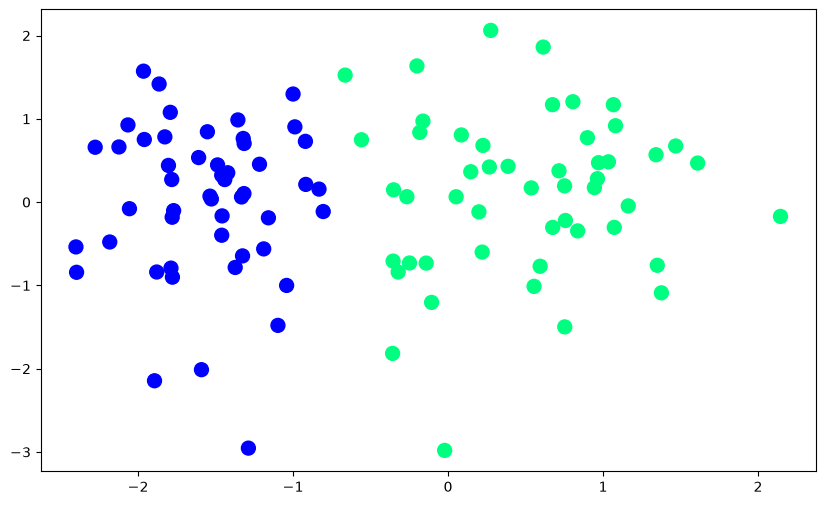

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [19]:


def perceptron(X, y):
    # Ensure labels are in {-1, +1} format
    y = np.where(y <= 0, -1, 1)
    
    # 2D features check (w1, w2, b)
    w1 = w2 = b = 1.0
    lr = 0.1
    
    for epoch in range(1000):
        total_errors = 0
        
        for i in range(X.shape[0]):
            # Linear dot product / sum calculation
            z = w1 * X[i][0] + w2 * X[i][1] + b

            # Misclassification Check: z * y_true <= 0
            if z * y[i] <= 0:
                w1 = w1 + lr * y[i] * X[i][0]
                w2 = w2 + lr * y[i] * X[i][1]
                b  = b  + lr * y[i]
                total_errors += 1
        
        # Early Stopping: Agar saare points correctly classify ho gaye to loop stop
        if total_errors == 0:
            print(f"Converged at Epoch {epoch + 1}")
            break
            
    return w1, w2, b

In [20]:
w1,w2,b = perceptron(X,y)

Converged at Epoch 2


In [21]:
b

np.float64(0.9)

In [22]:
m = -(w1/w2)
c = -(b/w2)

print(m,c)

-13.096388513261017 -8.492852183439245


(-3.0, 2.0)

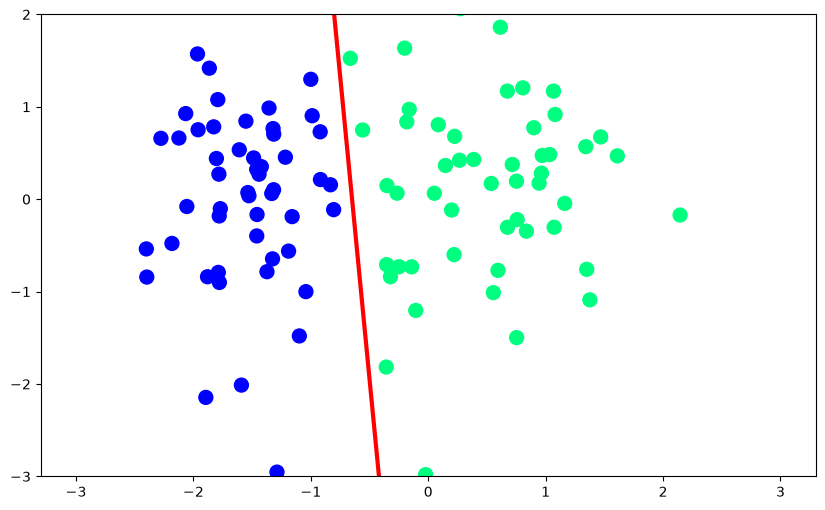

In [23]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + c

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)